# Stage 3: Network Stability Across Size, Shape, and Data Source

This notebook is organised to test **different network sizes and shapes**, keep the synthetic set to **3 clear families**, and then compare that synthetic picture against the **original empirical data**.


The workflow has three parts:

1. **Synthetic size/shape sweep** using three graph families: `ring`, `random`, and `modular`
2. **Empirical-scale replica test** where those synthetic families are rebuilt at the same 78-node scale as the data and compared with the empirical structural matrix
3. **Empirical fit test** against the control and glioma PLI matrices already stored in `data/`

That gives us a simple narrative:

- do the Hopf dynamics behave similarly across a few qualitatively different synthetic networks?
- when we rebuild those synthetic networks at the same scale as the real data, do they look anything like the empirical case?
- does the actual empirical structural matrix produce a better match to the empirical PLI targets than the synthetic stand-ins?

The defaults are still moderate so the notebook stays practical to run, but the code is written so that you can scale the experiments up later.


In [ ]:
import os
import sys
from pathlib import Path
from itertools import combinations

ROOT = Path.cwd()
if not (ROOT / "src" / "hopf_model.py").exists():
    ROOT = ROOT.parent
os.environ.setdefault("MPLCONFIGDIR", str(ROOT / ".matplotlib"))

import numpy as np
import matplotlib.pyplot as plt
from joblib import Parallel, delayed

if not (ROOT / "src" / "hopf_model.py").exists():
    ROOT = ROOT.parent
sys.path.append(str(ROOT / "src"))

FIG_DIR = ROOT / "figures" / "hopf model" / "network stability"
FIG_DIR.mkdir(parents=True, exist_ok=True)

from hopf_model import random_initial_conditions, simulate_hopf
from signal_processing import compute_phase, compute_pli

N_JOBS = int(os.environ.get("HOPF_N_JOBS", "-1"))

%matplotlib inline
plt.rcParams.update({"figure.dpi": 300, "font.size": 11})
RNG = np.random.default_rng(7)
print(f"Parallel workers: N_JOBS={N_JOBS}  (set HOPF_N_JOBS env var to override)")

## Helpers

The helpers below keep the notebook focused on the comparisons rather than the plumbing:

- graph generators for the three synthetic families
- normalization and summary utilities so different sizes are comparable
- repeated-simulation wrappers to measure initial-condition stability
- empirical-scale generators that rebuild synthetic networks at the same node count as the data


In [2]:
def upper_triangle_values(matrix):
    idx = np.triu_indices_from(matrix, k=1)
    return matrix[idx]


def nonzero_upper_triangle_values(matrix):
    values = upper_triangle_values(np.asarray(matrix, dtype=float))
    return values[np.abs(values) > 0]


def matrix_correlation(a, b):
    x = upper_triangle_values(np.asarray(a, dtype=float))
    y = upper_triangle_values(np.asarray(b, dtype=float))
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]
    if len(x) < 2:
        return np.nan
    if np.allclose(x.std(), 0.0) or np.allclose(y.std(), 0.0):
        return np.nan
    return float(np.corrcoef(x, y)[0, 1])


def pairwise_consistency(matrices):
    scores = []
    for a, b in combinations(matrices, 2):
        score = matrix_correlation(a, b)
        if np.isfinite(score):
            scores.append(score)
    if not scores:
        return np.nan
    return float(np.mean(scores))


def edge_density(W):
    upper = upper_triangle_values(np.asarray(W, dtype=float))
    return float(np.mean(np.abs(upper) > 0))


def normalize_weights(W, method="spectral"):
    W = np.asarray(W, dtype=float)
    W = W.copy()
    np.fill_diagonal(W, 0.0)
    if method == "max":
        scale = np.max(np.abs(W))
    elif method == "row":
        row_sums = np.sum(np.abs(W), axis=1)
        scale = np.max(row_sums)
    elif method == "spectral":
        eigvals = np.linalg.eigvalsh(W)
        scale = np.max(np.abs(eigvals))
    else:
        raise ValueError(f"Unknown normalization method: {method}")
    if not np.isfinite(scale) or scale == 0:
        return W
    return W / scale


def ring_network(n, weight=1.0):
    W = np.zeros((n, n))
    for i in range(n):
        W[i, (i - 1) % n] = weight
        W[i, (i + 1) % n] = weight
    return W


def erdos_renyi_network(n, p=0.2, rng=None, weighted=True):
    rng = np.random.default_rng(rng)
    mask = rng.uniform(size=(n, n)) < p
    mask = np.triu(mask, k=1)
    if weighted:
        weights = rng.uniform(0.2, 1.0, size=(n, n))
        W = np.where(mask, weights, 0.0)
    else:
        W = mask.astype(float)
    W = W + W.T
    return W


def modular_network(n, modules=3, p_in=0.7, p_out=0.08, rng=None):
    rng = np.random.default_rng(rng)
    groups = np.array_split(np.arange(n), modules)
    W = np.zeros((n, n))
    for g in groups:
        for i in g:
            for j in g:
                if i < j and rng.uniform() < p_in:
                    W[i, j] = rng.uniform(0.4, 1.0)
    for gi, gj in combinations(groups, 2):
        for i in gi:
            for j in gj:
                if rng.uniform() < p_out:
                    W[i, j] = rng.uniform(0.1, 0.5)
    W = W + W.T
    return W


def sample_weighted_graph_from_mask(mask, weight_bank, rng=None):
    rng = np.random.default_rng(rng)
    W = np.zeros(mask.shape, dtype=float)
    edge_count = int(np.count_nonzero(mask))
    if edge_count > 0:
        sampled = rng.choice(weight_bank, size=edge_count, replace=True)
        W[mask] = sampled
    W = W + W.T
    return W


def density_matched_random_network(reference_W, rng=None):
    rng = np.random.default_rng(rng)
    n = reference_W.shape[0]
    density = edge_density(reference_W)
    weight_bank = nonzero_upper_triangle_values(reference_W)
    mask = np.triu(rng.uniform(size=(n, n)) < density, k=1)
    return normalize_weights(
        sample_weighted_graph_from_mask(mask, weight_bank, rng=rng)
    )


def density_matched_modular_network(reference_W, modules=4, rng=None):
    rng = np.random.default_rng(rng)
    n = reference_W.shape[0]
    density = edge_density(reference_W)
    weight_bank = nonzero_upper_triangle_values(reference_W)
    groups = np.array_split(np.arange(n), modules)
    mask = np.zeros((n, n), dtype=bool)

    p_in = min(0.75, max(0.18, density * 2.8))
    p_out = min(0.18, max(0.01, density * 0.35))

    for g in groups:
        for i in g:
            for j in g:
                if i < j and rng.uniform() < p_in:
                    mask[i, j] = True
    for gi, gj in combinations(groups, 2):
        for i in gi:
            for j in gj:
                if rng.uniform() < p_out:
                    mask[i, j] = True

    if not np.any(mask):
        return density_matched_random_network(reference_W, rng=rng)
    return normalize_weights(
        sample_weighted_graph_from_mask(mask, weight_bank, rng=rng)
    )


def make_topology(name, n, rng=None):
    rng = np.random.default_rng(rng)
    if name == "ring":
        W = ring_network(n)
    elif name == "random":
        p = min(0.35, max(0.08, 3.0 / max(n - 1, 1)))
        W = erdos_renyi_network(n, p=p, rng=rng)
    elif name == "modular":
        W = modular_network(n, modules=min(4, max(2, n // 10 or 2)), rng=rng)
    else:
        raise ValueError(f"Unknown topology: {name}")

    if not np.any(W):
        W = ring_network(n)
    return normalize_weights(W)


def make_empirical_scale_topology(name, reference_W, rng=None):
    reference_W = np.asarray(reference_W, dtype=float)
    n = reference_W.shape[0]
    if name == "ring":
        return normalize_weights(ring_network(n))
    if name == "random":
        return density_matched_random_network(reference_W, rng=rng)
    if name == "modular":
        return density_matched_modular_network(reference_W, rng=rng)
    if name == "empirical":
        return normalize_weights(reference_W)
    raise ValueError(f"Unknown empirical-scale topology: {name}")


def load_empirical_frequency_bank(path):
    raw = np.genfromtxt(path, delimiter=",", skip_header=1)
    if raw.ndim == 1:
        values = raw[1:]
    else:
        values = raw[:, 1:]
    values = np.asarray(values, dtype=float).ravel()
    values = values[np.isfinite(values)]
    return values


def load_cortical_frequencies(path, n_cortical=78):
    """Subject-mean peak frequency for each of the first n_cortical AAL regions."""
    raw = np.genfromtxt(path, delimiter=",", skip_header=1)
    per_subject = raw[:, 1:n_cortical + 1]  # (subjects, 78)
    return np.nanmean(per_subject, axis=0)


def shuffle_sc(W, rng=None):
    """Randomly reassign upper-triangle edge weights, preserving the weight distribution."""
    rng = np.random.default_rng(rng)
    W = np.asarray(W, dtype=float).copy()
    upper = W[np.triu_indices_from(W, k=1)]
    rng.shuffle(upper)
    out = np.zeros_like(W)
    out[np.triu_indices_from(out, k=1)] = upper
    out = out + out.T
    return out


def sample_frequency_vector(n, rng=None, mode="alpha_jitter", empirical_bank=None):
    rng = np.random.default_rng(rng)
    if mode == "alpha_jitter":
        hz = rng.normal(loc=10.0, scale=0.8, size=n)
    elif mode == "empirical_bank":
        if empirical_bank is None or len(empirical_bank) == 0:
            raise ValueError("empirical_bank mode requires a non-empty empirical bank")
        hz = rng.choice(empirical_bank, size=n, replace=True)
    elif mode == "smooth_gradient":
        base = np.linspace(8.5, 10.5, n)
        hz = base + rng.normal(scale=0.15, size=n)
    else:
        raise ValueError(f"Unknown frequency mode: {mode}")
    hz = np.clip(hz, 8.0, 12.0)
    return hz


def simulate_pli_matrix(
    W, K, lam, freq_hz, C=20.0, seed=None, t_total=8.0, t_discard=1.5, fs=300
):
    W = np.asarray(W, dtype=float)
    n = W.shape[0]
    omega = 2 * np.pi * np.asarray(freq_hz, dtype=float)
    z0 = random_initial_conditions(n, rng=seed)
    _, x, _ = simulate_hopf(
        n,
        W,
        K,
        lam,
        C,
        omega,
        z0,
        t_total=t_total,
        t_discard=t_discard,
        fs=fs,
    )
    phases = compute_phase(x, fs=fs)
    pli = compute_pli(phases)
    return pli


def _run_one_repeat(W, K, lam, seed, freq_hz, t_total, t_discard, fs):
    """Single simulation returning a PLI matrix (picklable worker)."""
    return simulate_pli_matrix(
        W, K=K, lam=lam, freq_hz=freq_hz, seed=seed,
        t_total=t_total, t_discard=t_discard, fs=fs,
    )


def repeated_simulation_summary(
    W,
    K,
    lam,
    repeats=3,
    freq_mode="alpha_jitter",
    empirical_bank=None,
    fixed_freq=None,
    base_seed=0,
    t_total=8.0,
    t_discard=1.5,
    fs=300,
    n_jobs=1,
):
    seeds = [base_seed + rep for rep in range(repeats)]
    if fixed_freq is not None:
        freqs = [fixed_freq] * repeats
    else:
        freqs = [
            sample_frequency_vector(W.shape[0], rng=s, mode=freq_mode,
                                    empirical_bank=empirical_bank)
            for s in seeds
        ]

    plis = Parallel(n_jobs=n_jobs)(
        delayed(_run_one_repeat)(W, K, lam, s, f, t_total, t_discard, fs)
        for s, f in zip(seeds, freqs)
    )
    return {
        "mean_pli": np.mean(plis, axis=0),
        "consistency": pairwise_consistency(plis),
        "mean_strength": float(
            np.mean([upper_triangle_values(p).mean() for p in plis])
        ),
        "n_repeats": repeats,
    }


def _eval_one_gridpoint(i, j, W, K, lam, repeats, target_fc, fixed_freq,
                        freq_mode, empirical_bank, t_total, t_discard, fs):
    """Run all repeats for one (K, lam) grid point and return fit + stability."""
    plis = []
    scores = []
    for rep in range(repeats):
        seed = 1000 + 100 * i + 10 * j + rep
        if fixed_freq is not None:
            freq_hz = fixed_freq
        else:
            freq_hz = sample_frequency_vector(
                W.shape[0], rng=seed, mode=freq_mode,
                empirical_bank=empirical_bank,
            )
        pli = simulate_pli_matrix(
            W, K=K, lam=lam, freq_hz=freq_hz, seed=seed,
            t_total=t_total, t_discard=t_discard, fs=fs,
        )
        plis.append(pli)
        scores.append(matrix_correlation(pli, target_fc))
    return i, j, np.nanmean(scores), pairwise_consistency(plis)


def evaluate_empirical_fit(
    W,
    target_fc,
    K_values,
    lam_values,
    repeats=3,
    empirical_bank=None,
    fixed_freq=None,
    freq_mode="empirical_bank",
    t_total=8.0,
    t_discard=1.5,
    fs=300,
    n_jobs=1,
):
    fit = np.full((len(lam_values), len(K_values)), np.nan)
    stability = np.full_like(fit, np.nan)

    results = Parallel(n_jobs=n_jobs)(
        delayed(_eval_one_gridpoint)(
            i, j, W, K, lam, repeats, target_fc, fixed_freq,
            freq_mode, empirical_bank, t_total, t_discard, fs,
        )
        for i, lam in enumerate(lam_values)
        for j, K in enumerate(K_values)
    )
    for i, j, score, stab in results:
        fit[i, j] = score
        stability[i, j] = stab
    return fit, stability

# ── AAL78 region labels and functional-network colour map ──────────────────

AAL78_LABELS = [
    "Precentral L", "Precentral R",
    "Frontal Sup L", "Frontal Sup R",
    "Frontal Sup Orb L", "Frontal Sup Orb R",
    "Frontal Mid L", "Frontal Mid R",
    "Frontal Mid Orb L", "Frontal Mid Orb R",
    "Frontal Inf Oper L", "Frontal Inf Oper R",
    "Frontal Inf Tri L", "Frontal Inf Tri R",
    "Frontal Inf Orb L", "Frontal Inf Orb R",
    "Rolandic Oper L", "Rolandic Oper R",
    "SMA L", "SMA R",
    "Olfactory L", "Olfactory R",
    "Frontal Sup Med L", "Frontal Sup Med R",
    "Frontal Med Orb L", "Frontal Med Orb R",
    "Rectus L", "Rectus R",
    "Insula L", "Insula R",
    "Cingulate Ant L", "Cingulate Ant R",
    "Cingulate Mid L", "Cingulate Mid R",
    "Cingulate Post L", "Cingulate Post R",
    "Hippocampus L", "Hippocampus R",
    "ParaHippocampal L", "ParaHippocampal R",
    "Amygdala L", "Amygdala R",
    "Calcarine L", "Calcarine R",
    "Cuneus L", "Cuneus R",
    "Lingual L", "Lingual R",
    "Occipital Sup L", "Occipital Sup R",
    "Occipital Mid L", "Occipital Mid R",
    "Occipital Inf L", "Occipital Inf R",
    "Fusiform L", "Fusiform R",
    "Postcentral L", "Postcentral R",
    "Parietal Sup L", "Parietal Sup R",
    "Parietal Inf L", "Parietal Inf R",
    "SupraMarginal L", "SupraMarginal R",
    "Angular L", "Angular R",
    "Precuneus L", "Precuneus R",
    "Paracentral Lob L", "Paracentral Lob R",
    "Caudate L", "Caudate R",
    "Putamen L", "Putamen R",
    "Pallidum L", "Pallidum R",
    "Thalamus L", "Thalamus R",
]

NETWORK_NAMES = [
    "Somatomotor", "Somatomotor",
    "Frontoparietal", "Frontoparietal",
    "Limbic", "Limbic",
    "Ventral Attn", "Ventral Attn",
    "Limbic", "Limbic",
    "Ventral Attn", "Ventral Attn",
    "Frontoparietal", "Frontoparietal",
    "Limbic", "Limbic",
    "Somatomotor", "Somatomotor",
    "Somatomotor", "Somatomotor",
    "Limbic", "Limbic",
    "Default Mode", "Default Mode",
    "Limbic", "Limbic",
    "Limbic", "Limbic",
    "Ventral Attn", "Ventral Attn",
    "Default Mode", "Default Mode",
    "Default Mode", "Default Mode",
    "Default Mode", "Default Mode",
    "Limbic", "Limbic",
    "Limbic", "Limbic",
    "Limbic", "Limbic",
    "Visual", "Visual",
    "Visual", "Visual",
    "Visual", "Visual",
    "Visual", "Visual",
    "Visual", "Visual",
    "Visual", "Visual",
    "Visual", "Visual",
    "Somatomotor", "Somatomotor",
    "Dorsal Attn", "Dorsal Attn",
    "Dorsal Attn", "Dorsal Attn",
    "Ventral Attn", "Ventral Attn",
    "Default Mode", "Default Mode",
    "Default Mode", "Default Mode",
    "Somatomotor", "Somatomotor",
    "Subcortical", "Subcortical",
    "Subcortical", "Subcortical",
    "Subcortical", "Subcortical",
    "Subcortical", "Subcortical",
]

NETWORK_COLORS = {
    "Visual":       "#9B59B6",
    "Somatomotor":  "#3498DB",
    "Dorsal Attn":  "#2ECC71",
    "Ventral Attn": "#E74C3C",
    "Limbic":       "#F39C12",
    "Frontoparietal":"#1ABC9C",
    "Default Mode": "#E91E63",
    "Subcortical":  "#7F8C8D",
}


def plot_labelled_matrix(ax, mat, title, cmap="plasma", vmin=None, vmax=None,
                         labels=None, networks=None, net_colors=None,
                         label_fontsize=3.2, cbar=True, fig=None):
    """Plot a matrix with AAL78 region labels coloured by functional network."""
    if labels is None:
        labels = AAL78_LABELS
    if networks is None:
        networks = NETWORK_NAMES
    if net_colors is None:
        net_colors = NETWORK_COLORS

    n = mat.shape[0]
    if vmax is None:
        vmax = mat.max() if mat.max() > 0 else 1
    if vmin is None:
        vmin = 0

    im = ax.imshow(mat, cmap=cmap, vmin=vmin, vmax=vmax, aspect="equal")
    ax.set_title(title, fontsize=9, pad=4)

    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(labels[:n], fontsize=label_fontsize, rotation=90)
    ax.set_yticklabels(labels[:n], fontsize=label_fontsize)

    for idx in range(n):
        col = net_colors.get(networks[idx], "#333333")
        ax.get_xticklabels()[idx].set_color(col)
        ax.get_yticklabels()[idx].set_color(col)

    ax.tick_params(length=0)

    if cbar and fig is not None:
        fig.colorbar(im, ax=ax, shrink=0.75, pad=0.02)

    return im


## 1. Synthetic networks: three shapes across a few sizes

To keep the experiment readable, we use exactly **three** synthetic graph families:

- **ring**: regular local coupling
- **random**: irregular connectivity with no obvious mesoscale structure
- **modular**: clustered connectivity, which is the most brain-like of the three synthetic options

We then repeat each simulation several times with new initial conditions and frequency draws.

Two summary metrics matter here:

- **IC stability**: correlation between FC matrices across repeated runs
- **SC-FC alignment**: correlation between structural weights and the mean simulated PLI matrix

This is the direct response to the "different size and shape networks" idea before touching the empirical data.


In [3]:
SYNTHETIC_SIZES = [10, 30, 78]
SYNTHETIC_TOPOLOGIES = ["ring", "random", "modular"]
SYNTHETIC_K_VALUES = [0.5, 1.5, 3.0]
SYNTHETIC_LAM = 1.0
SYNTHETIC_REPEATS = 3
FAST_SIM_KWARGS = dict(t_total=6.5, t_discard=1.5, fs=250)

In [4]:
synthetic_results = []

for topology in SYNTHETIC_TOPOLOGIES:
    for n in SYNTHETIC_SIZES:
        W = make_topology(topology, n, rng=RNG.integers(0, 1_000_000))
        for K in SYNTHETIC_K_VALUES:
            summary = repeated_simulation_summary(
                W,
                K=K,
                lam=SYNTHETIC_LAM,
                repeats=SYNTHETIC_REPEATS,
                base_seed=10_000 + 100 * n + int(10 * K),
                **FAST_SIM_KWARGS,
            )
            synthetic_results.append(
                {
                    "topology": topology,
                    "n": n,
                    "K": K,
                    "consistency": summary["consistency"],
                    "strength": summary["mean_strength"],
                    "sc_fc": matrix_correlation(W, summary["mean_pli"]),
                }
            )

print(f"Completed {len(synthetic_results)} synthetic experiments.")

Completed 27 synthetic experiments.


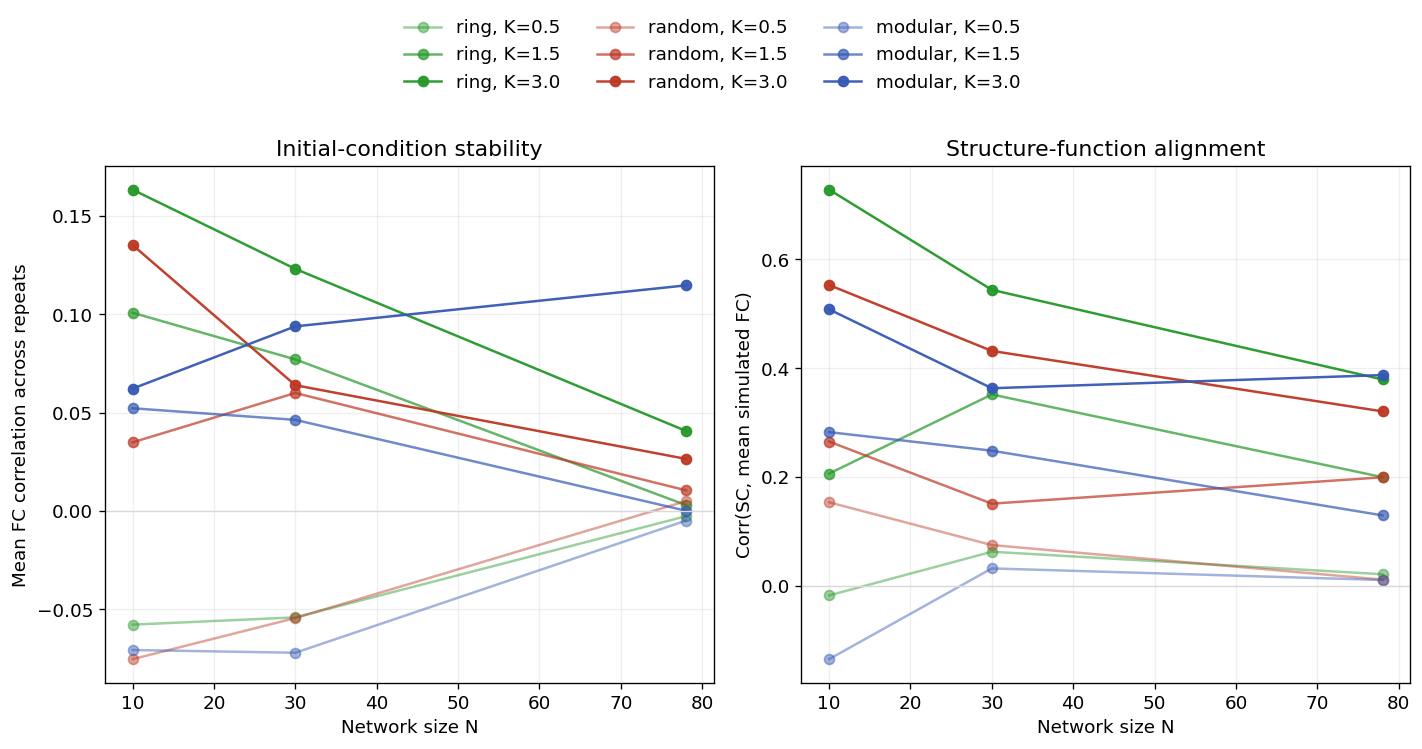

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.2), sharex=True)
colors = {
    "ring": "#259829",
    "random": "#bc3824",
    "modular": "#3558b2",
}

for topology in SYNTHETIC_TOPOLOGIES:
    for K in SYNTHETIC_K_VALUES:
        subset = [
            r for r in synthetic_results if r["topology"] == topology and r["K"] == K
        ]
        subset = sorted(subset, key=lambda r: r["n"])
        n_vals = [r["n"] for r in subset]
        consistency = [r["consistency"] for r in subset]
        sc_fc = [r["sc_fc"] for r in subset]
        label = f"{topology}, K={K}"
        alpha = {0.5: 0.45, 1.5: 0.7, 3.0: 0.95}[K]
        axes[0].plot(
            n_vals,
            consistency,
            marker="o",
            lw=1.5,
            color=colors[topology],
            alpha=alpha,
            label=label,
        )
        axes[1].plot(
            n_vals,
            sc_fc,
            marker="o",
            lw=1.5,
            color=colors[topology],
            alpha=alpha,
            label=label,
        )

axes[0].set(
    title="Initial-condition stability",
    xlabel="Network size N",
    ylabel="Mean FC correlation across repeats",
)
axes[1].set(
    title="Structure-function alignment",
    xlabel="Network size N",
    ylabel="Corr(SC, mean simulated FC)",
)
for ax in axes:
    ax.axhline(0, color="0.85", lw=0.8)
    ax.grid(alpha=0.2)

handles, labels = axes[1].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    ncols=3,
    loc="lower center",
    bbox_to_anchor=(0.5, 1.12),
    frameon=False,
)
fig.tight_layout(rect=[0, 0.08, 1, 1.1])
fig.savefig(FIG_DIR / "synthetic_sweep.png", dpi=300, bbox_inches="tight")

### Inspect one synthetic example

This quick visual check makes it easy to see one member of the synthetic family before moving to the empirical-scale comparison.


IC stability: -0.019
SC-FC alignment: 0.266


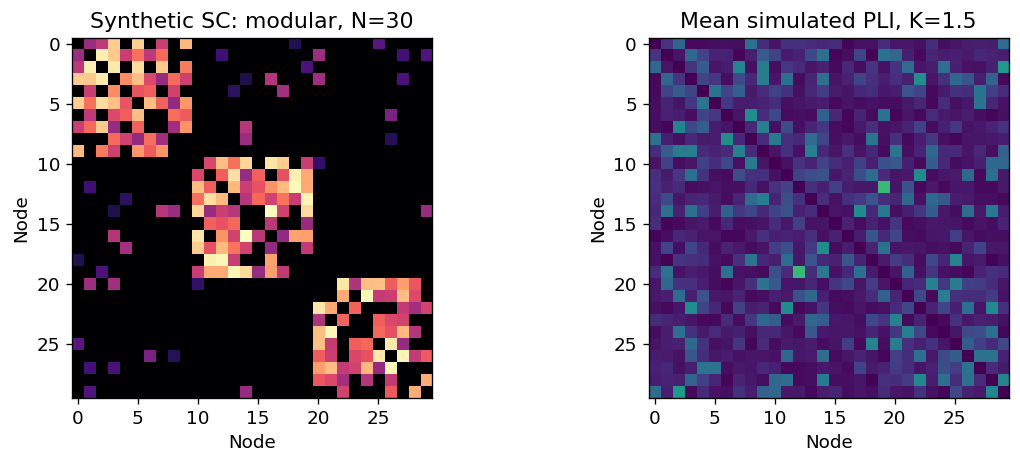

In [6]:
EXAMPLE_TOPOLOGY = "modular"
EXAMPLE_N = 30
EXAMPLE_K = 1.5
EXAMPLE_LAM = 1.0

W_example = make_topology(EXAMPLE_TOPOLOGY, EXAMPLE_N, rng=123)
example_summary = repeated_simulation_summary(
    W_example,
    K=EXAMPLE_K,
    lam=EXAMPLE_LAM,
    repeats=3,
    base_seed=1234,
    **FAST_SIM_KWARGS,
)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(W_example, cmap="plasma")
axes[0].set_title(f"Synthetic SC: {EXAMPLE_TOPOLOGY}, N={EXAMPLE_N}")
axes[1].imshow(example_summary["mean_pli"], cmap="plasma", vmin=0, vmax=1)
axes[1].set_title(f"Mean simulated PLI, K={EXAMPLE_K}")
for ax in axes:
    ax.set_xlabel("Node")
    ax.set_ylabel("Node")
fig.tight_layout()

print(f"IC stability: {example_summary['consistency']:.3f}")
print(
    f"SC-FC alignment: {matrix_correlation(W_example, example_summary['mean_pli']):.3f}"
)
fig.savefig(FIG_DIR / "synthetic_example_inspection.png", dpi=300, bbox_inches="tight")

## 2. Empirical-scale replica test

Before fitting the real structural matrix directly, we rebuild the synthetic families at the same **78-node scale** as the empirical network.

This is the closest thing to a synthetic replica of the empirical setup:

- same number of nodes as the data
- empirical frequency bank for `omega_i` sampling
- one extra comparison case using the actual empirical structural matrix itself

If the empirical structural matrix is doing something meaningful, it should usually outperform the synthetic stand-ins when compared against the empirical PLI targets.


In [7]:
SC_EMP = normalize_weights(
    np.loadtxt(ROOT / "data" / "structural_connectivity_matrix.csv", delimiter=",")
)
CONTROL_PLI = np.loadtxt(ROOT / "data" / "control_PLI_raw.csv", delimiter=",")
GLIOMA_PLI = np.loadtxt(ROOT / "data" / "glioma_PLI_raw.csv", delimiter=",")
CONTROL_PLI_THR = np.loadtxt(ROOT / "data" / "control_PLI_top3percent.csv", delimiter=",")
GLIOMA_PLI_THR = np.loadtxt(ROOT / "data" / "glioma_PLI_top3percent.csv", delimiter=",")

FREQ_BANK = load_empirical_frequency_bank(ROOT / "data" / "exp_frequencies.csv")
CORTICAL_FREQ = load_cortical_frequencies(ROOT / "data" / "exp_frequencies.csv")

print("SC shape:", SC_EMP.shape)
print("Control PLI shape:", CONTROL_PLI.shape)
print("Glioma PLI shape:", GLIOMA_PLI.shape)
print(f"Empirical SC density: {edge_density(SC_EMP):.3f}")
print(f"Cortical frequency vector: {CORTICAL_FREQ.shape} — "
      f"range {CORTICAL_FREQ.min():.1f}–{CORTICAL_FREQ.max():.1f} Hz, "
      f"mean {CORTICAL_FREQ.mean():.1f} Hz")
print(f"Frequency bank size: {len(FREQ_BANK)} (all 116 regions × 27 subjects)")
print(f"Thresholded PLI nonzero edges: {np.count_nonzero(CONTROL_PLI_THR)} (control), "
      f"{np.count_nonzero(GLIOMA_PLI_THR)} (glioma)")

SC shape: (78, 78)
Control PLI shape: (78, 78)
Glioma PLI shape: (78, 78)
Empirical SC density: 0.162
Frequency bank size: 3132
Frequency range: 4.57 to 23.78 Hz


In [8]:
REPLICA_TOPOLOGIES = ["ring", "random", "modular", "empirical"]
REPLICA_K_VALUES = [0.5, 1.5, 3.0]
REPLICA_LAM = 1.0
REPLICA_REPEATS = 3
REPLICA_SIM_KWARGS = dict(t_total=6.5, t_discard=1.5, fs=250)

replica_results = []

for topology in REPLICA_TOPOLOGIES:
    W_replica = make_empirical_scale_topology(
        topology, SC_EMP, rng=RNG.integers(0, 1_000_000)
    )
    for K in REPLICA_K_VALUES:
        summary = repeated_simulation_summary(
            W_replica,
            K=K,
            lam=REPLICA_LAM,
            repeats=REPLICA_REPEATS,
            empirical_bank=FREQ_BANK,
            freq_mode="empirical_bank",
            base_seed=30_000 + int(100 * K),
            **REPLICA_SIM_KWARGS,
        )
        replica_results.append(
            {
                "topology": topology,
                "K": K,
                "consistency": summary["consistency"],
                "strength": summary["mean_strength"],
                "fit_control": matrix_correlation(summary["mean_pli"], CONTROL_PLI),
                "fit_glioma": matrix_correlation(summary["mean_pli"], GLIOMA_PLI),
                "sc_similarity": matrix_correlation(W_replica, SC_EMP),
            }
        )

print(f"Completed {len(replica_results)} empirical-scale replica experiments.")

Completed 12 empirical-scale replica experiments.


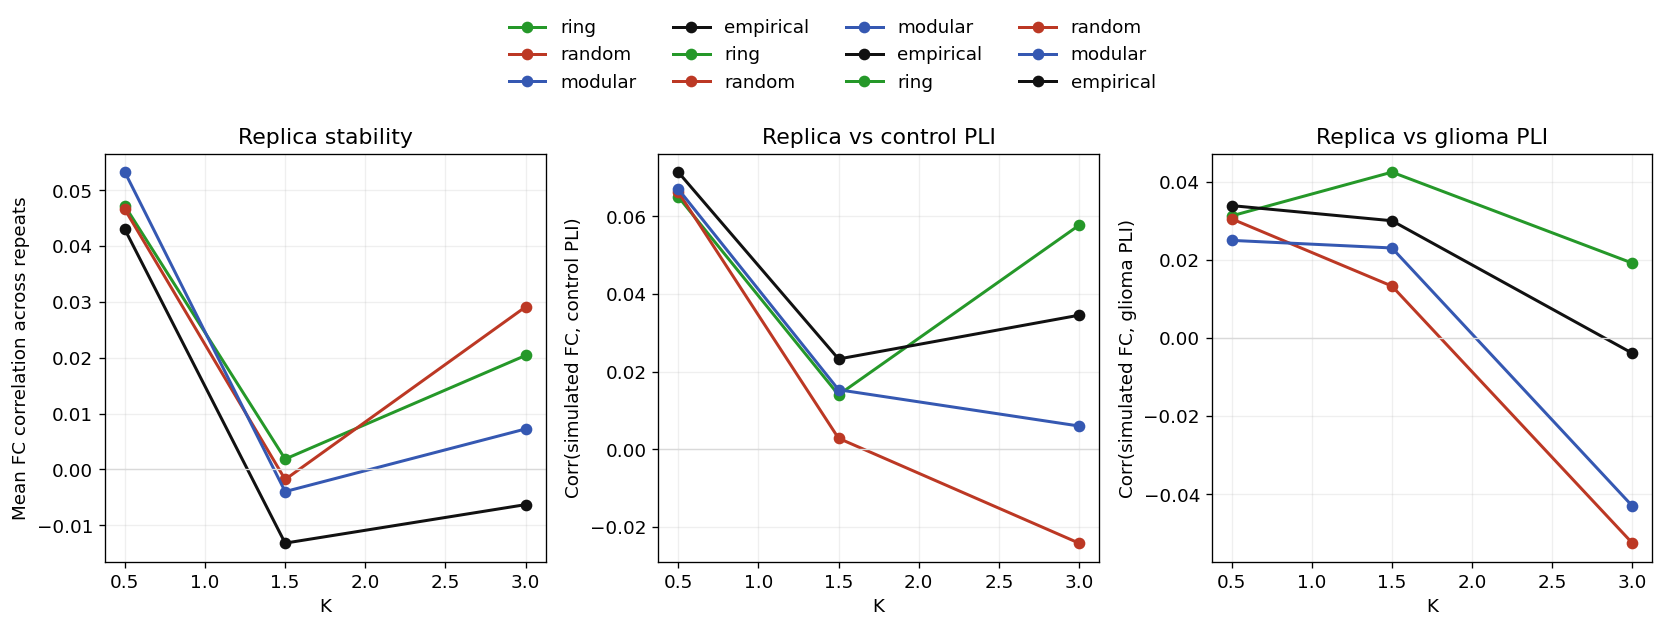

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.4), sharex=True)
colors = {
    "ring": "#259829",
    "random": "#bc3824",
    "modular": "#3558b2",
    "empirical": "#111111",
}

for topology in REPLICA_TOPOLOGIES:
    subset = [r for r in replica_results if r["topology"] == topology]
    subset = sorted(subset, key=lambda r: r["K"])
    k_vals = [r["K"] for r in subset]
    axes[0].plot(
        k_vals,
        [r["consistency"] for r in subset],
        marker="o",
        lw=1.8,
        color=colors[topology],
        label=topology,
    )
    axes[1].plot(
        k_vals,
        [r["fit_control"] for r in subset],
        marker="o",
        lw=1.8,
        color=colors[topology],
        label=topology,
    )
    axes[2].plot(
        k_vals,
        [r["fit_glioma"] for r in subset],
        marker="o",
        lw=1.8,
        color=colors[topology],
        label=topology,
    )

axes[0].set(
    title="Replica stability", xlabel="K", ylabel="Mean FC correlation across repeats"
)
axes[1].set(
    title="Replica vs control PLI", xlabel="K", ylabel="Corr(simulated FC, control PLI)"
)
axes[2].set(
    title="Replica vs glioma PLI", xlabel="K", ylabel="Corr(simulated FC, glioma PLI)"
)
for ax in axes:
    ax.axhline(0, color="0.85", lw=0.8)
    ax.grid(alpha=0.2)

fig.legend(ncols=4, loc="lower center", bbox_to_anchor=(0.5, 1.02), frameon=False)
fig.tight_layout(rect=[0, 0.02, 1, 1.02])
fig.savefig(FIG_DIR / "replica_comparison.png", dpi=300, bbox_inches="tight")

## 2.5 Sanity-check: inspect the 78-node dynamics before fitting

Before optimising $(K, \lambda)$, we run one simulation at a reasonable
parameter set and verify that the model produces sensible oscillatory
dynamics at scale.

Checks:
- **Time series** for a handful of nodes — should show sustained alpha-band oscillations.
- **Power spectra** — dominant peaks should sit near each node’s intrinsic frequency.
- **PLI distribution** — compare the shape against the empirical PLI distribution.


In [ ]:
SANITY_K = 1.5
SANITY_LAM = 1.0

PAPER_SIM_KW = dict(t_total=14.5, t_discard=1.0, fs=1250)

omega_sanity = 2 * np.pi * CORTICAL_FREQ
z0_sanity = random_initial_conditions(78, rng=42)
t_san, x_san, y_san = simulate_hopf(
    78, SC_EMP, SANITY_K, SANITY_LAM, 20.0, omega_sanity, z0_sanity,
    **PAPER_SIM_KW,
)

example_nodes = [0, 19, 38, 57, 72]

fig, axes = plt.subplots(len(example_nodes), 1, figsize=(12, 8), sharex=True)
for ax, node in zip(axes, example_nodes):
    ax.plot(t_san, x_san[node], lw=0.4)
    ax.set_ylabel(f"Node {node}\n({CORTICAL_FREQ[node]:.1f} Hz)")
axes[-1].set_xlabel("Time (s)")
axes[0].set_title(f"78-node time series (K={SANITY_K}, $\\lambda$={SANITY_LAM})")
fig.tight_layout()
fig.savefig(FIG_DIR / "sanity_time_series.png", dpi=300, bbox_inches="tight")
print(f"Simulation: {x_san.shape[1]} samples, {t_san[-1]:.1f} s after discard")
print(f"(Paper settings: t_total={PAPER_SIM_KW['t_total']}, "
      f"fs={PAPER_SIM_KW['fs']}, t_discard={PAPER_SIM_KW['t_discard']})")

In [ ]:
SANITY_FS = PAPER_SIM_KW["fs"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for node, col in zip(example_nodes, plt.cm.tab10.colors):
    freqs = np.fft.rfftfreq(x_san.shape[1], d=1.0 / SANITY_FS)
    spectrum = np.abs(np.fft.rfft(x_san[node])) ** 2
    spectrum /= spectrum.max()
    axes[0].plot(freqs, spectrum, lw=0.8, color=col,
                 label=f"Node {node} ({CORTICAL_FREQ[node]:.1f} Hz)")
axes[0].set_xlim(2, 20)
axes[0].set_xlabel("Frequency (Hz)")
axes[0].set_ylabel("Normalised power")
axes[0].set_title("Power spectra of example nodes")
axes[0].legend(fontsize=7)

phases_sanity = compute_phase(x_san, fs=SANITY_FS)
pli_sanity = compute_pli(phases_sanity)

sim_upper = upper_triangle_values(pli_sanity)
emp_upper = upper_triangle_values(CONTROL_PLI)

axes[1].hist(emp_upper, bins=40, alpha=0.5, density=True, label="Control (empirical)")
axes[1].hist(sim_upper, bins=40, alpha=0.5, density=True, label="Simulated")
axes[1].set_xlabel("PLI")
axes[1].set_ylabel("Density")
axes[1].set_title("PLI distribution: simulated vs empirical")
axes[1].legend(fontsize=8)

fig.tight_layout()
fig.savefig(FIG_DIR / "sanity_spectra_pli_dist.png", dpi=300, bbox_inches="tight")

print(f"Simulated PLI range: {sim_upper.min():.3f} \u2013 {sim_upper.max():.3f}")
print(f"Empirical PLI range: {emp_upper.min():.4f} \u2013 {emp_upper.max():.4f}")
print(f"SC-FC alignment: {matrix_correlation(SC_EMP, pli_sanity):.3f}")

## 3. Parameter fit (Paper Figure 2)

We perform a two-dimensional grid search over the coupling strength $K$ and
excitability $\lambda$ to find the optimal parameterisation, then generate
publication-quality PLI matrices at the best-fit parameters.

The combined figure reproduces the paper's Figure 2:
- **(a)** Simulated functional connectivity (PLI) at optimal parameters
- **(b)** Structural connectivity (averaged control connectome)
- **(c)** Empirical functional connectivity (averaged control PLI)
- **(d)** Model fit heatmap — Pearson correlation across the $(K, \lambda)$ grid

In [ ]:
DENSE_LAM = np.linspace(-50, 50, 50)
DENSE_K   = np.linspace(0.5, 50, 50)
DENSE_N_IC = 30      # paper uses 500; 30 gives a smooth heatmap at reasonable cost
GRID_SIM_KW = dict(t_total=8.0, t_discard=1.5, fs=300)


def _dense_one_point(i, j, K, lam, W, freq, target, n_ic, sim_kw):
    """Run all ICs for one grid point and return mean Pearson correlation."""
    scores = []
    for ic in range(n_ic):
        seed = 7000 + 100 * i + 10 * j + ic
        pli = simulate_pli_matrix(
            W, K=K, lam=lam, freq_hz=freq, seed=seed, **sim_kw,
        )
        scores.append(matrix_correlation(pli, target))
    return i, j, np.nanmean(scores)


print(f"Running {len(DENSE_K)}x{len(DENSE_LAM)} dense grid "
      f"({DENSE_N_IC} ICs each, {len(DENSE_K)*len(DENSE_LAM)*DENSE_N_IC:,} total sims) ...")
print(f"Grid sim settings: {GRID_SIM_KW}")

results = Parallel(n_jobs=N_JOBS, verbose=5)(
    delayed(_dense_one_point)(
        i, j, K, lam, SC_EMP, CORTICAL_FREQ, CONTROL_PLI, DENSE_N_IC, GRID_SIM_KW,
    )
    for i, K in enumerate(DENSE_K)
    for j, lam in enumerate(DENSE_LAM)
)

dense_fit = np.full((len(DENSE_K), len(DENSE_LAM)), np.nan)
for i, j, val in results:
    dense_fit[i, j] = val

print("Dense grid done.")

In [ ]:
best_dense_idx = np.unravel_index(np.nanargmax(dense_fit), dense_fit.shape)
dense_best_K = DENSE_K[best_dense_idx[0]]
dense_best_lam = DENSE_LAM[best_dense_idx[1]]

print(f"Best-fit parameters: K={dense_best_K:.2f}, lambda={dense_best_lam:.2f}, "
      f"r={dense_fit[best_dense_idx]:.3f}")
print(f"Generating paper-quality PLI (50 ICs, {PAPER_SIM_KW}) ...")

dense_summary = repeated_simulation_summary(
    SC_EMP,
    K=dense_best_K, lam=dense_best_lam,
    repeats=50,
    fixed_freq=CORTICAL_FREQ,
    base_seed=80_000,
    n_jobs=N_JOBS,
    **PAPER_SIM_KW,
)

# ── 2x2 Figure 2 reproduction ─────────────────────────────────────────────
fig = plt.figure(figsize=(20, 18))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.25)

ax_a = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[0, 1])
ax_c = fig.add_subplot(gs[1, 0])
ax_d = fig.add_subplot(gs[1, 1])

# (a) Simulated functional connectivity
plot_labelled_matrix(
    ax_a, dense_summary["mean_pli"],
    "(a)  Simulated functional connectivity",
    fig=fig,
)

# (b) Structural connectivity
plot_labelled_matrix(
    ax_b, SC_EMP,
    "(b)  Structural connectivity",
    cmap="plasma", fig=fig,
)

# (c) Empirical functional connectivity
plot_labelled_matrix(
    ax_c, CONTROL_PLI,
    "(c)  Empirical functional connectivity",
    vmax=CONTROL_PLI.max(), fig=fig,
)

# (d) Model fit
im_d = ax_d.pcolormesh(
    DENSE_LAM, DENSE_K, dense_fit,
    cmap="plasma", shading="nearest",
)
ax_d.set_xlabel("Excitability", fontsize=11)
ax_d.set_ylabel("Coupling Strength", fontsize=11)
ax_d.set_title("(d)  Model fit", fontsize=9, pad=4)
fig.colorbar(im_d, ax=ax_d, label="Pearson correlation", shrink=0.75, pad=0.02)

# Network legend
handles = [plt.Line2D([0], [0], marker="s", color="w",
                       markerfacecolor=c, markersize=8, label=n)
           for n, c in NETWORK_COLORS.items()]
fig.legend(handles=handles, loc="upper right", fontsize=8,
           title="Functional network labels", title_fontsize=9,
           bbox_to_anchor=(0.99, 0.99), framealpha=0.9)

fig.savefig(FIG_DIR / "fig2_combined.png", dpi=300, bbox_inches="tight")
print(f"Simulated-control PLI correlation: "
      f"{matrix_correlation(dense_summary['mean_pli'], CONTROL_PLI):.3f}")

## 4. Null-model control: shuffled structural connectivity

A positive correlation between simulated and empirical PLI could arise simply
because both matrices are symmetric and non-negative.  To test whether the
**specific topology** of the empirical SC matters, we shuffle its edge weights
(preserving the weight distribution but destroying spatial structure) and rerun
the simulations at the best-fit parameters from the dense grid.

In [ ]:
N_SHUFFLES = 5

real_ctrl_corr = matrix_correlation(dense_summary["mean_pli"], CONTROL_PLI)
real_glio_corr = matrix_correlation(dense_summary["mean_pli"], GLIOMA_PLI)


def _run_one_shuffle(i, SC, K, lam, cortical_freq, sim_kw):
    W_shuf = shuffle_sc(SC, rng=2000 + i)
    shuf_summary = repeated_simulation_summary(
        W_shuf,
        K=K,
        lam=lam,
        repeats=2,
        fixed_freq=cortical_freq,
        base_seed=50_000 + i * 100,
        **sim_kw,
    )
    ctrl = matrix_correlation(shuf_summary["mean_pli"], CONTROL_PLI)
    glio = matrix_correlation(shuf_summary["mean_pli"], GLIOMA_PLI)
    return ctrl, glio


shuffle_results = Parallel(n_jobs=N_JOBS)(
    delayed(_run_one_shuffle)(
        i, SC_EMP, dense_best_K, dense_best_lam, CORTICAL_FREQ, PAPER_SIM_KW,
    )
    for i in range(N_SHUFFLES)
)
shuffle_ctrl_corrs = [r[0] for r in shuffle_results]
shuffle_glio_corrs = [r[1] for r in shuffle_results]

print(f"Real SC \u2192 control fit:  {real_ctrl_corr:.3f}")
print(f"Shuffled SC \u2192 control:  {np.mean(shuffle_ctrl_corrs):.3f} \u00b1 {np.std(shuffle_ctrl_corrs):.3f}")
print(f"Real SC \u2192 glioma fit:   {real_glio_corr:.3f}")
print(f"Shuffled SC \u2192 glioma:   {np.mean(shuffle_glio_corrs):.3f} \u00b1 {np.std(shuffle_glio_corrs):.3f}")

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))

x_pos = [0, 1]
bar_width = 0.35
ctrl_vals = [real_ctrl_corr, np.mean(shuffle_ctrl_corrs)]
glio_vals = [real_glio_corr, np.mean(shuffle_glio_corrs)]
ctrl_err = [0, np.std(shuffle_ctrl_corrs)]
glio_err = [0, np.std(shuffle_glio_corrs)]

ax.bar([p - bar_width / 2 for p in x_pos], ctrl_vals, bar_width,
       yerr=ctrl_err, capsize=4, label="Control", color="C0", alpha=0.8)
ax.bar([p + bar_width / 2 for p in x_pos], glio_vals, bar_width,
       yerr=glio_err, capsize=4, label="Glioma", color="C1", alpha=0.8)

ax.set_xticks(x_pos)
ax.set_xticklabels(["Real SC", f"Shuffled SC\n(n={N_SHUFFLES})"])
ax.set_ylabel("Corr(simulated PLI, empirical PLI)")
ax.set_title(f"Null-model test: real vs shuffled SC "
             f"(K={dense_best_K:.1f}, $\\lambda$={dense_best_lam:.1f})")
ax.legend()
ax.axhline(0, color="0.8", lw=0.8)
fig.tight_layout()
fig.savefig(FIG_DIR / "null_model_comparison.png", dpi=300, bbox_inches="tight")

## 5. Thresholded PLI comparison

The paper's main analyses use **top-3% thresholded** PLI matrices, which keep
only the strongest ~90 edges.  Here we compare raw and thresholded PLI for
the best-fit simulation against both the control and glioma empirical data.

In [ ]:
from signal_processing import threshold_pli

sim_pli_best = dense_summary["mean_pli"]
sim_pli_thr = threshold_pli(sim_pli_best, percentile=97)

raw_ctrl = matrix_correlation(sim_pli_best, CONTROL_PLI)
raw_glio = matrix_correlation(sim_pli_best, GLIOMA_PLI)
thr_ctrl = matrix_correlation(sim_pli_thr, CONTROL_PLI_THR)
thr_glio = matrix_correlation(sim_pli_thr, GLIOMA_PLI_THR)

print(f"Raw PLI fit:         control {raw_ctrl:.3f},  glioma {raw_glio:.3f}")
print(f"Thresholded PLI fit: control {thr_ctrl:.3f},  glioma {thr_glio:.3f}")

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

panels = [
    (sim_pli_best, "Simulated PLI (raw)"),
    (CONTROL_PLI, "Control PLI (raw)"),
    (GLIOMA_PLI, "Glioma PLI (raw)"),
    (sim_pli_thr, "Simulated PLI (top 3%)"),
    (CONTROL_PLI_THR, "Control PLI (top 3%)"),
    (GLIOMA_PLI_THR, "Glioma PLI (top 3%)"),
]

for ax, (mat, title) in zip(axes.flat, panels):
    vmax = mat.max() if mat.max() > 0 else 1
    plot_labelled_matrix(ax, mat, title, vmax=vmax, fig=fig)

fig.suptitle(f"Raw vs thresholded PLI comparison "
             f"(K={dense_best_K:.1f}, $\\lambda$={dense_best_lam:.1f})",
             y=1.01, fontsize=12)
fig.tight_layout()
fig.savefig(FIG_DIR / "raw_vs_thresholded_pli.png", dpi=300, bbox_inches="tight")

## 6. Log-log grid with scaling law (Paper Figure 3)

The paper demonstrates that the PLI goodness-of-fit is invariant under
$K \propto \sqrt{\lambda}$ by showing the grid search on **log\u2013log axes**.

Grey dashed lines show $K = \kappa\sqrt{\lambda}$ for several values of the
normalised coupling strength $\kappa$.

Panel **(A)** averages over many ICs; panels **(B\u2013F)** show individual ICs.

In [ ]:
LOG_K   = np.logspace(-1, 2, 30)     # 0.1 to 100
LOG_LAM = np.logspace(-1, 2, 30)     # 0.1 to 100
LOG_N_IC = 30       # paper uses 300; 30 gives smooth panels at reasonable cost
LOG_SIM_KW = GRID_SIM_KW


def _log_one_point(i, j, lam, K, W, freq, target, n_ic, sim_kw):
    """Run all ICs for one log-grid point, returning per-IC scores."""
    scores = []
    for ic in range(n_ic):
        seed = 30_000 + 1000 * ic + 100 * i + j
        pli = simulate_pli_matrix(
            W, K=K, lam=lam, freq_hz=freq, seed=seed, **sim_kw,
        )
        scores.append(matrix_correlation(pli, target))
    return i, j, scores


print(f"Running {len(LOG_K)}x{len(LOG_LAM)} log-log grid "
      f"({LOG_N_IC} ICs each, {len(LOG_K)*len(LOG_LAM)*LOG_N_IC:,} total sims) ...")

results = Parallel(n_jobs=N_JOBS, verbose=5)(
    delayed(_log_one_point)(
        i, j, lam, K, SC_EMP, CORTICAL_FREQ, CONTROL_PLI, LOG_N_IC, LOG_SIM_KW,
    )
    for i, lam in enumerate(LOG_LAM)
    for j, K in enumerate(LOG_K)
)

log_fits_per_ic = np.full((LOG_N_IC, len(LOG_LAM), len(LOG_K)), np.nan)
for i, j, scores in results:
    for ic, s in enumerate(scores):
        log_fits_per_ic[ic, i, j] = s

log_fit_mean = np.nanmean(log_fits_per_ic, axis=0)
print("Log-log grid done.")

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

kappa_values = [0.3, 1.0, 3.0, 10.0]
lam_line = np.logspace(-1, 2, 300)

panel_labels = ["(a)", "(b)", "(c)", "(d)", "(e)", "(f)"]
panel_titles = [
    f"Average over initial conditions",
    "Initial condition 1",
    "Initial condition 2",
    "Initial condition 3",
    "Initial condition 4",
    "Initial condition 5",
]
panel_data = [log_fit_mean] + [log_fits_per_ic[p] for p in range(5)]

for ax, label, title, grid in zip(axes.flat, panel_labels, panel_titles, panel_data):
    im = ax.pcolormesh(
        LOG_K, LOG_LAM, grid, cmap="plasma", shading="nearest",
    )
    ax.set_xscale("log")
    ax.set_yscale("log")
    for kap in kappa_values:
        ax.plot(kap * np.sqrt(lam_line), lam_line, "--", color="0.55", lw=0.8)
    ax.set_xlabel("Excitability", fontsize=10)
    ax.set_ylabel("Coupling strength", fontsize=10)
    ax.set_title(f"{label}  {title}", fontsize=10, pad=4)
    fig.colorbar(im, ax=ax, shrink=0.8, label="Pearson correlation", pad=0.02)

for kap in kappa_values:
    axes[0, 0].annotate(
        f"$\\kappa$={kap}",
        xy=(kap * np.sqrt(lam_line[-1]), lam_line[-1]),
        fontsize=6, color="0.4", ha="left",
    )

fig.tight_layout()
fig.savefig(FIG_DIR / "fig3_loglog_grid.png", dpi=300, bbox_inches="tight")

## 7. Glioma cohort fitting (Paper Figure 4)

We repeat the log-log grid search from Section 6, fitting to the **glioma**
cohort's averaged PLI instead of controls. From both grids we extract the
optimal coupling strength $K^*(\lambda)$ per initial condition, fit
$K = \kappa\sqrt{\lambda}$ by least-squares regression, and compare the
normalised coupling strength $\kappa$ between the two cohorts.

The paper demonstrates that the glioma cohort requires a **higher** normalised
coupling strength, suggesting increased interregional functional coupling.

In [ ]:
# ── Glioma log-log grid (reuses _log_one_point from Section 6) ────────
print(f"Running {len(LOG_K)}x{len(LOG_LAM)} log-log grid for GLIOMA target "
      f"({LOG_N_IC} ICs each, {len(LOG_K)*len(LOG_LAM)*LOG_N_IC:,} sims) ...")

glioma_log_results = Parallel(n_jobs=N_JOBS, verbose=5)(
    delayed(_log_one_point)(
        i, j, lam, K, SC_EMP, CORTICAL_FREQ, GLIOMA_PLI, LOG_N_IC, LOG_SIM_KW,
    )
    for i, lam in enumerate(LOG_LAM)
    for j, K in enumerate(LOG_K)
)

glioma_fits_per_ic = np.full((LOG_N_IC, len(LOG_LAM), len(LOG_K)), np.nan)
for i, j, scores in glioma_log_results:
    for ic, s in enumerate(scores):
        glioma_fits_per_ic[ic, i, j] = s

glioma_fit_mean = np.nanmean(glioma_fits_per_ic, axis=0)
print("Glioma log-log grid done.")

# ── Extract optimal K*(λ) per IC for both cohorts ─────────────────────
ctrl_Kopt_idx = np.argmax(log_fits_per_ic, axis=2)      # (n_ic, n_lam)
glio_Kopt_idx = np.argmax(glioma_fits_per_ic, axis=2)

ctrl_Kopt = LOG_K[ctrl_Kopt_idx]   # (n_ic, n_lam)
glio_Kopt = LOG_K[glio_Kopt_idx]

ctrl_Kopt_mean = ctrl_Kopt.mean(axis=0)
ctrl_Kopt_std  = ctrl_Kopt.std(axis=0)
glio_Kopt_mean = glio_Kopt.mean(axis=0)
glio_Kopt_std  = glio_Kopt.std(axis=0)

# ── Fit κ by least-squares: K = κ√λ  (only for λ ≥ 1) ───────────────
mask_fit = LOG_LAM >= 1.0
sqrt_lam = np.sqrt(LOG_LAM[mask_fit])

kappa_ctrl = float(np.linalg.lstsq(
    sqrt_lam[:, None], ctrl_Kopt_mean[mask_fit], rcond=None)[0][0])
kappa_glio = float(np.linalg.lstsq(
    sqrt_lam[:, None], glio_Kopt_mean[mask_fit], rcond=None)[0][0])

print(f"Fitted κ  control: {kappa_ctrl:.3f}")
print(f"Fitted κ  glioma:  {kappa_glio:.3f}")
print(f"Ratio κ_glioma / κ_control: {kappa_glio / kappa_ctrl:.3f}")

In [ ]:
# ── Figure 4 reproduction ────────────────────────────────────────────
fig = plt.figure(figsize=(18, 6))
gs = fig.add_gridspec(1, 3, wspace=0.35)
ax_a, ax_b, ax_c = [fig.add_subplot(gs[0, k]) for k in range(3)]

lam_reg = np.logspace(-1, 2, 300)

# (a) Optimal K vs λ with std shading and regression lines
ax_a.plot(LOG_LAM, ctrl_Kopt_mean, 'b-', lw=1.5, label='Control')
ax_a.fill_between(LOG_LAM,
                   np.maximum(ctrl_Kopt_mean - ctrl_Kopt_std, 1e-2),
                   ctrl_Kopt_mean + ctrl_Kopt_std, alpha=0.2, color='b')
ax_a.plot(LOG_LAM, glio_Kopt_mean, 'r-', lw=1.5, label='Glioma')
ax_a.fill_between(LOG_LAM,
                   np.maximum(glio_Kopt_mean - glio_Kopt_std, 1e-2),
                   glio_Kopt_mean + glio_Kopt_std, alpha=0.2, color='r')
ax_a.plot(lam_reg, kappa_ctrl * np.sqrt(lam_reg), 'b--', lw=1,
          label=f'$\\kappa_{{ctrl}}={kappa_ctrl:.2f}$')
ax_a.plot(lam_reg, kappa_glio * np.sqrt(lam_reg), 'r--', lw=1,
          label=f'$\\kappa_{{glio}}={kappa_glio:.2f}$')
ax_a.set_xscale('log'); ax_a.set_yscale('log')
ax_a.set_xlabel('Excitability', fontsize=11)
ax_a.set_ylabel('Coupling strength', fontsize=11)
ax_a.set_title('(a)  Optimal coupling vs excitability', fontsize=10)
ax_a.legend(fontsize=8)

# (b) Control grid with regression line
im_b = ax_b.pcolormesh(LOG_K, LOG_LAM, log_fit_mean,
                        cmap='plasma', shading='nearest')
ax_b.plot(kappa_ctrl * np.sqrt(lam_reg), lam_reg, 'b--', lw=1.5,
          label=f'$\\kappa={kappa_ctrl:.2f}$')
ax_b.set_xscale('log'); ax_b.set_yscale('log')
ax_b.set_xlabel('Coupling strength', fontsize=11)
ax_b.set_ylabel('Excitability', fontsize=11)
ax_b.set_title('(b)  Control cohort fit', fontsize=10)
ax_b.legend(fontsize=8, loc='lower right')
fig.colorbar(im_b, ax=ax_b, shrink=0.8, label='Pearson r', pad=0.02)

# (c) Glioma grid with regression line
im_c = ax_c.pcolormesh(LOG_K, LOG_LAM, glioma_fit_mean,
                        cmap='plasma', shading='nearest')
ax_c.plot(kappa_glio * np.sqrt(lam_reg), lam_reg, 'r--', lw=1.5,
          label=f'$\\kappa={kappa_glio:.2f}$')
ax_c.set_xscale('log'); ax_c.set_yscale('log')
ax_c.set_xlabel('Coupling strength', fontsize=11)
ax_c.set_ylabel('Excitability', fontsize=11)
ax_c.set_title('(c)  Glioma cohort fit', fontsize=10)
ax_c.legend(fontsize=8, loc='lower right')
fig.colorbar(im_c, ax=ax_c, shrink=0.8, label='Pearson r', pad=0.02)

fig.savefig(FIG_DIR / 'fig4_glioma_comparison.png', dpi=300, bbox_inches='tight')
print(f'κ_control = {kappa_ctrl:.3f},  κ_glioma = {kappa_glio:.3f}')

## 8. Distribution of optimal coupling differences (Paper Figure 5)

For several fixed excitability values $\lambda$, we find the optimal coupling
strength $K^*$ per initial condition for both the control and glioma cohorts.
The distributions of $\Delta K = K^*_{\text{glioma}} - K^*_{\text{control}}$
reveal whether the glioma cohort consistently requires higher coupling.

Wilcoxon signed-rank tests assess whether the difference distributions have
zero mean. The paper reports highly significant results ($p < 0.001$) with
positive mean differences.

In [ ]:
from scipy.stats import wilcoxon

FIG5_LAMS = [0, 10, 20, 30, 40]
FIG5_K    = np.linspace(0.5, 50, 40)
FIG5_N_IC = 100     # paper uses 1000; 100 keeps runtime practical


def _fig5_sweep(ic, lam, K_vals, W, freq, tgt_ctrl, tgt_glio, sim_kw):
    """Sweep K at fixed (IC, λ), return optimal K for both targets."""
    seed = 60_000 + ic
    ctrl_scores = np.empty(len(K_vals))
    glio_scores = np.empty(len(K_vals))
    for k, K in enumerate(K_vals):
        pli = simulate_pli_matrix(W, K=K, lam=lam, freq_hz=freq,
                                  seed=seed, **sim_kw)
        ctrl_scores[k] = matrix_correlation(pli, tgt_ctrl)
        glio_scores[k] = matrix_correlation(pli, tgt_glio)
    return (ic, lam,
            K_vals[np.nanargmax(ctrl_scores)],
            K_vals[np.nanargmax(glio_scores)])


print(f"Figure 5 sweep: {len(FIG5_LAMS)} λ values × {FIG5_N_IC} ICs "
      f"× {len(FIG5_K)} K values = "
      f"{len(FIG5_LAMS)*FIG5_N_IC*len(FIG5_K):,} sims ...")

fig5_results = Parallel(n_jobs=N_JOBS, verbose=5)(
    delayed(_fig5_sweep)(
        ic, lam, FIG5_K, SC_EMP, CORTICAL_FREQ,
        CONTROL_PLI, GLIOMA_PLI, GRID_SIM_KW,
    )
    for lam in FIG5_LAMS
    for ic in range(FIG5_N_IC)
)

fig5_deltaK = {lam: [] for lam in FIG5_LAMS}
fig5_ctrl_K = {lam: [] for lam in FIG5_LAMS}
fig5_glio_K = {lam: [] for lam in FIG5_LAMS}
for ic, lam, Kc, Kg in fig5_results:
    fig5_deltaK[lam].append(Kg - Kc)
    fig5_ctrl_K[lam].append(Kc)
    fig5_glio_K[lam].append(Kg)

# Wilcoxon tests
print("\nWilcoxon signed-rank tests (H0: ΔK = 0):")
print(f"{'λ':>5}  {'mean ΔK':>9}  {'statistic':>12}  {'p-value':>10}")
print("-" * 42)
for lam in FIG5_LAMS:
    dK = np.array(fig5_deltaK[lam])
    nonzero = dK[dK != 0]
    if len(nonzero) > 10:
        stat, pval = wilcoxon(nonzero)
    else:
        stat, pval = np.nan, np.nan
    print(f"{lam:5d}  {dK.mean():9.3f}  {stat:12.2e}  {pval:10.4e}")

# Pooled distribution
all_deltaK = np.concatenate([fig5_deltaK[lam] for lam in FIG5_LAMS])
nonzero_all = all_deltaK[all_deltaK != 0]
if len(nonzero_all) > 10:
    stat_all, pval_all = wilcoxon(nonzero_all)
else:
    stat_all, pval_all = np.nan, np.nan
print(f"{'pool':>5}  {all_deltaK.mean():9.3f}  {stat_all:12.2e}  {pval_all:10.4e}")

In [ ]:
# ── Figure 5: histograms of ΔK ──────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

panels = list(zip(FIG5_LAMS, 'abcde')) + [('pooled', 'f')]

for ax, (lam_val, letter) in zip(axes.flat, panels):
    if lam_val == 'pooled':
        dK = all_deltaK
        title = f'({letter})  All λ pooled'
    else:
        dK = np.array(fig5_deltaK[lam_val])
        title = f'({letter})  λ = {lam_val}'

    ax.hist(dK, bins=25, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(0, color='k', ls='--', lw=1, label='ΔK = 0')
    ax.axvline(dK.mean(), color='dodgerblue', ls='--', lw=1.2,
               label=f'mean = {dK.mean():.2f}')
    ax.set_xlabel('$\\Delta K$ (glioma − control)', fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=7)

fig.suptitle('Distribution of optimal coupling difference '
             '(glioma − control) over initial conditions',
             fontsize=12, y=1.01)
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig5_deltaK_distributions.png',
            dpi=300, bbox_inches='tight')

## 9. Functional connectotomy (Paper Figures 6–8)

The paper's key result: removing tumor-affected regions from the goodness-of-fit
evaluation ("functional connectotomy") reveals that tumors contribute to the
pathologically high coupling strength in glioma patients.

**Limitation:** We do not have individual patient PLI matrices or patient-specific
tumor masks. We demonstrate the connectotomy methodology on the **averaged**
glioma PLI using plausible tumor region sets derived from common glioma locations
in the AAL78 atlas (frontal and temporal regions, consistent with the paper's
Figure 7).

The procedure:
1. For fixed $\lambda$, sweep $K$ and find $K^*$ fitting the full glioma PLI
2. Repeat, but **mask** tumor-region rows and columns when computing the
   Pearson correlation (the model still simulates all 78 regions)
3. $\Delta K^* < 0$ after connectotomy means the tumors were driving
   the higher coupling strength

In [ ]:
# ── Define example tumor region sets ──────────────────────────────────
TUMOR_SETS = {
    'Frontal L':    [2, 4, 6, 10, 12, 14, 22, 24],
    'Temporal L':   [28, 36, 38],
    'Frontal R':    [3, 5, 7, 11, 13, 15, 23, 25],
    'All tumors':   [2, 3, 4, 5, 6, 7, 10, 11, 12, 13, 14, 15,
                     22, 23, 24, 25, 28, 36, 38],
}

print('Tumor region sets:')
for name, idxs in TUMOR_SETS.items():
    labels = [AAL78_LABELS[i] for i in idxs]
    print(f'  {name} ({len(idxs)} regions): {", ".join(labels)}')


def masked_correlation(sim_pli, emp_pli, mask_indices):
    """Pearson correlation ignoring rows/columns in mask_indices."""
    keep = np.ones(sim_pli.shape[0], dtype=bool)
    keep[mask_indices] = False
    sub_sim = sim_pli[np.ix_(keep, keep)]
    sub_emp = emp_pli[np.ix_(keep, keep)]
    return matrix_correlation(sub_sim, sub_emp)


def _connectotomy_sweep(ic, lam, K_vals, W, freq, emp_full, emp_ctrl,
                        tumor_idx, sim_kw):
    """Find optimal K with and without connectotomy, for patient and control."""
    seed = 70_000 + ic
    n_K = len(K_vals)
    full_glio  = np.empty(n_K)
    mask_glio  = np.empty(n_K)
    full_ctrl  = np.empty(n_K)
    mask_ctrl  = np.empty(n_K)
    for k, K in enumerate(K_vals):
        pli = simulate_pli_matrix(W, K=K, lam=lam, freq_hz=freq,
                                  seed=seed, **sim_kw)
        full_glio[k] = matrix_correlation(pli, emp_full)
        mask_glio[k] = masked_correlation(pli, emp_full, tumor_idx)
        full_ctrl[k] = matrix_correlation(pli, emp_ctrl)
        mask_ctrl[k] = masked_correlation(pli, emp_ctrl, tumor_idx)
    return (ic,
            K_vals[np.nanargmax(full_glio)],
            K_vals[np.nanargmax(mask_glio)],
            K_vals[np.nanargmax(full_ctrl)],
            K_vals[np.nanargmax(mask_ctrl)])

In [ ]:
# ── Run connectotomy for each tumor set ──────────────────────────────
CONN_LAM   = 40
CONN_K     = np.linspace(0.5, 50, 40)
CONN_N_IC  = 100      # paper uses 500; 100 is practical

connectotomy_results = {}

for name, tumor_idx in TUMOR_SETS.items():
    print(f'Connectotomy: {name} ({len(tumor_idx)} regions) ...')

    res = Parallel(n_jobs=N_JOBS, verbose=1)(
        delayed(_connectotomy_sweep)(
            ic, CONN_LAM, CONN_K, SC_EMP, CORTICAL_FREQ,
            GLIOMA_PLI, CONTROL_PLI, tumor_idx, GRID_SIM_KW,
        )
        for ic in range(CONN_N_IC)
    )

    K_glio_full = np.array([r[1] for r in res])
    K_glio_mask = np.array([r[2] for r in res])
    K_ctrl_full = np.array([r[3] for r in res])
    K_ctrl_mask = np.array([r[4] for r in res])

    dK_glio = K_glio_mask - K_glio_full
    dK_ctrl = K_ctrl_mask - K_ctrl_full
    dK_relative = dK_glio - dK_ctrl

    connectotomy_results[name] = {
        'K_glio_full': K_glio_full, 'K_glio_mask': K_glio_mask,
        'K_ctrl_full': K_ctrl_full, 'K_ctrl_mask': K_ctrl_mask,
        'dK_glio': dK_glio, 'dK_ctrl': dK_ctrl,
        'dK_relative': dK_relative,
    }

    nonzero = dK_relative[dK_relative != 0]
    if len(nonzero) > 10:
        stat, pval = wilcoxon(nonzero)
    else:
        stat, pval = np.nan, np.nan
    print(f'  mean ΔK(glioma): {dK_glio.mean():.2f}, '
          f'mean ΔK(ctrl): {dK_ctrl.mean():.2f}, '
          f'relative: {dK_relative.mean():.2f}, '
          f'Wilcoxon p={pval:.2e}\n')

In [ ]:
# ── Figure 6-8 equivalent: connectotomy results ─────────────────────
tumor_names = list(connectotomy_results.keys())
n_sets = len(tumor_names)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# (a) Box plots: K* before/after connectotomy for glioma
ax = axes[0, 0]
positions = np.arange(n_sets)
bp1 = ax.boxplot(
    [connectotomy_results[n]['K_glio_full'] for n in tumor_names],
    positions=positions - 0.18, widths=0.3, patch_artist=True,
    boxprops=dict(facecolor='#E74C3C', alpha=0.6),
    medianprops=dict(color='black'), showfliers=False,
)
bp2 = ax.boxplot(
    [connectotomy_results[n]['K_glio_mask'] for n in tumor_names],
    positions=positions + 0.18, widths=0.3, patch_artist=True,
    boxprops=dict(facecolor='#3498DB', alpha=0.6),
    medianprops=dict(color='black'), showfliers=False,
)
ax.set_xticks(positions)
ax.set_xticklabels(tumor_names, fontsize=9)
ax.set_ylabel('Optimal coupling strength $K^*$', fontsize=10)
ax.set_title(f'(a)  Glioma $K^*$ before/after connectotomy (λ={CONN_LAM})',
             fontsize=10)
ax.legend([bp1['boxes'][0], bp2['boxes'][0]],
          ['Full PLI', 'After connectotomy'], fontsize=8)

# (b) Histograms of relative ΔK for each set
ax = axes[0, 1]
colors = ['#E74C3C', '#3498DB', '#2ECC71', '#9B59B6']
for i, name in enumerate(tumor_names):
    dK = connectotomy_results[name]['dK_relative']
    ax.hist(dK, bins=20, alpha=0.5, color=colors[i % len(colors)],
            label=f'{name} (μ={dK.mean():.1f})', edgecolor='white')
ax.axvline(0, color='k', ls='--', lw=1)
ax.set_xlabel('$\\Delta K^*$ relative to control', fontsize=10)
ax.set_ylabel('Count', fontsize=10)
ax.set_title('(b)  Connectotomy effect (relative to control)', fontsize=10)
ax.legend(fontsize=7)

# (c) Tumor regions highlighted on SC
ax = axes[1, 0]
sc_highlight = SC_EMP.copy()
all_tumor = TUMOR_SETS['All tumors']
im = ax.imshow(sc_highlight, cmap='plasma', aspect='equal')
for idx in all_tumor:
    ax.axhline(idx, color='red', alpha=0.3, lw=0.5)
    ax.axvline(idx, color='red', alpha=0.3, lw=0.5)
ax.set_title('(c)  Tumor regions on structural connectivity', fontsize=10)
ax.set_xlabel('Region', fontsize=10)
ax.set_ylabel('Region', fontsize=10)
fig.colorbar(im, ax=ax, shrink=0.8, pad=0.02)

# (d) Summary bar chart: mean ΔK per tumor set
ax = axes[1, 1]
means = [connectotomy_results[n]['dK_relative'].mean() for n in tumor_names]
sems  = [connectotomy_results[n]['dK_relative'].std()
         / np.sqrt(CONN_N_IC) for n in tumor_names]
bars = ax.bar(positions, means, yerr=sems, capsize=4,
              color=colors[:n_sets], alpha=0.7, edgecolor='white')
ax.axhline(0, color='k', ls='-', lw=0.8)
ax.set_xticks(positions)
ax.set_xticklabels(tumor_names, fontsize=9)
ax.set_ylabel('Mean $\\Delta K^*$ (relative to control)', fontsize=10)
ax.set_title('(d)  Connectotomy summary', fontsize=10)

fig.suptitle(f'Functional connectotomy analysis (λ = {CONN_LAM}, '
             f'{CONN_N_IC} ICs)', fontsize=12, y=1.01)
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig6_8_connectotomy.png', dpi=300, bbox_inches='tight')
print('Connectotomy figure saved.')

## Summary

| Section | What it tests | Key question |
|---|---|---|
| **1. Synthetic sweep** | Ring, random, modular at N = 10, 30, 78 | Are IC stability and SC-FC alignment robust across topologies and sizes? |
| **2. Empirical-scale replicas** | Synthetic families rebuilt at 78 nodes + empirical SC | Does the real structural matrix outperform generic stand-ins? |
| **2.5 Dynamics sanity check** | One 78-node simulation with empirical SC and cortical frequencies | Do the oscillations, spectra, and PLI structure look reasonable? |
| **3. Parameter fit (Fig 2)** | Dense grid + labelled PLI matrices in a single 2×2 panel | Reproduce the paper's Figure 2: simulated PLI (a), SC (b), empirical PLI (c), model fit heatmap (d) |
| **4. Null model** | Shuffled SC (topology destroyed, weights preserved) | Does the specific wiring of the empirical SC matter? |
| **5. Thresholded PLI** | Raw vs top-3% thresholded comparison | Does the fit hold when only the strongest functional connections are retained? |
| **6. Log-log scaling (Fig 3)** | Log-spaced grid with $K = \kappa\sqrt{\lambda}$ lines | Confirm the scaling-law invariance of the goodness of fit |
| **7. Glioma fitting (Fig 4)** | Log-log grid for glioma cohort + $\kappa$ regression | Higher normalised coupling in glioma vs control? |
| **8. Coupling distributions (Fig 5)** | Per-IC optimal $K$ at fixed $\lambda$ values + Wilcoxon tests | Statistically significant difference in coupling between cohorts? |
| **9. Functional connectotomy (Figs 6–8)** | Mask tumor regions from fit evaluation | Do tumors contribute to pathologically high coupling? |

### Saved figures

| File | Paper figure | What it shows |
|---|---|---|
| `synthetic_sweep.png` | — | IC stability and SC-FC alignment across synthetic networks |
| `synthetic_example_inspection.png` | — | Example PLI matrix and time series for one synthetic network |
| `replica_comparison.png` | — | Empirical-scale replicas: synthetic vs real SC |
| `sanity_time_series.png` | — | 78-node time series for 5 representative nodes |
| `sanity_spectra_pli_dist.png` | — | Power spectra + PLI distribution (simulated vs empirical) |
| `fig2_combined.png` | **Fig 2** | 2×2 panel: simulated PLI (a), structural connectivity (b), empirical PLI (c), model fit heatmap (d) |
| `null_model_comparison.png` | — | Real SC vs shuffled SC fit quality |
| `raw_vs_thresholded_pli.png` | — | Raw and top-3% PLI matrices (labelled) |
| `fig3_loglog_grid.png` | **Fig 3** | Log-log grid with $\kappa$ scaling lines |
| `fig4_glioma_comparison.png` | **Fig 4** | Control vs glioma grids + $\kappa$ regression |
| `fig5_deltaK_distributions.png` | **Fig 5** | Histograms of $\Delta K$ between cohorts over ICs |
| `fig6_8_connectotomy.png` | **Figs 6–8** | Functional connectotomy: $K^*$ before/after + summary |